In [ ]:
"""
=============================================================================
案例教程 21: 基因组学端到端机器学习流水线 — TCGA 癌症类型分类
=============================================================================
教学目标: 在 TCGA 基因表达数据上跑通【完整的 ML 流程】, 并在每一步显式对照
         前面教程 01-12 的知识点, 让学生看清"从临床表格数据迁移到高维基因组
         学数据, 哪些步骤完全相同, 哪些步骤因数据特性而不同".

本脚本 = 一个综合案例, 覆盖机器学习的全部步骤:
  ① EDA           → 对照教程 01
  ② 统计分析      → 对照教程 02
  ③ 预处理        → 对照教程 03/04 (标准化, 防泄漏)
  ④ 特征选择      → 对照教程 05 (★基因组学最常用: LASSO 基因签名)
  ⑤ 防泄漏        → 对照教程 07 (Pipeline + 仅训练集选择)
  ⑥ 交叉验证      → 对照教程 08 (重复分层 K-Fold)
  ⑦ 建模对比      → 对照教程 09 (LR/SVM/RF/XGBoost/LightGBM)
  ⑧ 类别不平衡    → 对照教程 10 (COAD 少数类, class_weight)
  ⑨ 校准与混淆矩阵 → 对照教程 11 (多分类: 混淆矩阵 + per-class ROC + DCA)
  ⑩ SHAP 可解释   → 对照教程 12 (多分类 SHAP)

任务: 用 20531 个基因的 mRNA 表达值预测 5 种癌症类型
      (BRCA 乳腺癌 / KIRC 肾透明细胞癌 / LUAD 肺腺癌 / PRAD 前列腺癌 / COAD 结肠腺癌)
      这是经典的 p≫n (特征远多于样本) 高维多分类问题.

为什么特征选择用 LASSO?
  - 用户问题: "基因组学特征会很多, 选一个最常用的方法"
  - 答: LASSO (L1 正则逻辑回归) 是基因 signature 论文的事实标准.
    原因: ① 自动稀疏 (系数压到 0 = 自动选基因); ② 可解释 (线性系数 = 基因权重);
          ③ p≫n 时仍稳定 (L1 在特征数 >> 样本数时是少数能求解的方法);
          ④ 与样本量适配. 见 Golub et al., Science 1999; Tibshirani 1996.
  - 本脚本采用标准基因组学流程: 方差预筛 → ANOVA 单变量筛 → LASSO 稀疏 → gene signature

与教程 20 (影像组学) 的关键差异:
  - 维度更高: 20531 基因 vs 93 影像组学特征 → 必须两步预筛再上 LASSO
  - 多分类: 5 类 vs 二分类 → 指标改用 macro-F1 / 混淆矩阵 / per-class ROC
  - 无缺失值: 基因表达已归一化 → 跳过插补 (教程 03 的方法此处可跳过)
  - 类别略失衡: BRCA 300 vs COAD 78 → 用 class_weight (教程 10)
=============================================================================
"""


In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import (train_test_split, RepeatedStratifiedKFold,
                                     cross_val_score, StratifiedKFold)
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, roc_curve, auc, brier_score_loss,
                             precision_score, recall_score, cohen_kappa_score,
                             matthews_corrcoef, balanced_accuracy_score,
                             precision_recall_curve, average_precision_score,
                             classification_report)
from sklearn.calibration import calibration_curve

import xgboost as xgb
import lightgbm as lgb
import shap

warnings.filterwarnings('ignore')
import logging as _logging
_logging.getLogger('shap').setLevel(_logging.ERROR)   # 抑制 shap 冗余日志

In [2]:
BASE_DIR = ".."
DATA_DIR = os.path.join(BASE_DIR, "data", "gene_data")
DATA_CSV = os.path.join(DATA_DIR, "data.csv")
LABELS_CSV = os.path.join(DATA_DIR, "labels.csv")
IMG_DIR = os.path.join(BASE_DIR, "img")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 基因组学特征选择标准流程的两个预筛阈值 (经验值, 可调)
ANOVA_TOP_K = 2000   # 方差/ANOVA 单变量预筛保留的基因数 (LASSO 前的常规做法)
CORR_THRESHOLD = 0.9  # 去冗余相关性阈值

In [3]:

# ============================================================================
# 0. 加载基因表达数据
# ============================================================================
print("\n[0] 加载 TCGA 基因表达数据 ...")
X_df = pd.read_csv(DATA_CSV, index_col=0)
y_df = pd.read_csv(LABELS_CSV, index_col=0)
print(f"    样本数: {len(X_df)}  |  基因数(特征): {X_df.shape[1]}")
print(f"    → p≫n 严重 (特征 {X_df.shape[1]} 远多于样本 {len(X_df)})")

le = LabelEncoder()
y = le.fit_transform(y_df.iloc[:, 0].values)
class_names = list(le.classes_)           # ['BRCA','COAD','KIRC','LUAD','PRAD'] (按字母序)
n_classes = len(class_names)
X = X_df.values.astype(float)
feat_names = np.array(X_df.columns.tolist())

print(f"    类别 (5 类癌症): {class_names}")
print(f"    各类样本数:")
for cname, cnt in zip(*np.unique(y_df.iloc[:, 0].values, return_counts=True)):
    print(f"       {cname}: {cnt}")


[0] 加载 TCGA 基因表达数据 ...
    样本数: 801  |  基因数(特征): 20531
    → p≫n 严重 (特征 20531 远多于样本 801)
    类别 (5 类癌症): ['BRCA', 'COAD', 'KIRC', 'LUAD', 'PRAD']
    各类样本数:
       BRCA: 300
       COAD: 78
       KIRC: 146
       LUAD: 141
       PRAD: 136


In [4]:

# ----------------------------------------------------------------------------
# 防泄漏第 1 步: 先划分 train/test, 之后所有 fit 都只在 train 上 (教程 07)
# - stratify=y 保证 5 类比例在 train/test 一致 (教程 08 的分层划分)
# ----------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"    训练集: {len(X_train)}  测试集: {len(X_test)}  (分层划分, 5 类比例保留)")

    训练集: 640  测试集: 161  (分层划分, 5 类比例保留)



① EDA 探索性数据分析  (对照教程 01)

  ▶ 基因表达值跨度: 中位数=6.65  最大=20.78
     → 不同基因表达跨度差异 2 个数量级, 仍需标准化 (教程 03/04)
  ▶ 基因零值比例: 均值=14.2%  中位数=0.0%
     → 超过 50% 零值的基因: 2810 个 (低表达基因, 需方差预筛)
  ▶ 5 类样本数: {'BRCA': np.int64(300), 'COAD': np.int64(78), 'KIRC': np.int64(146), 'LUAD': np.int64(141), 'PRAD': np.int64(136)}
     → 最大/最小类比例 = 3.8  (BRCA 最多, COAD 最少, 轻度不平衡)
  [图] 21_eda_overview.png → 类别分布+基因表达分布已保存


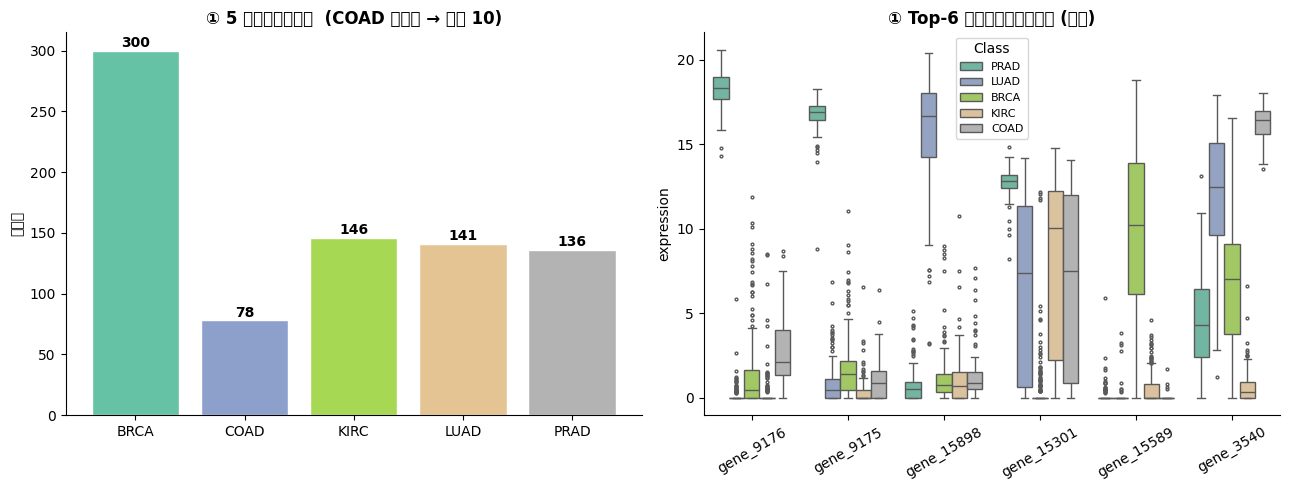

In [5]:

# ============================================================================
# ① EDA — 对照教程 01
# ============================================================================
print("\n" + "=" * 70)
print("① EDA 探索性数据分析  (对照教程 01)")
print("=" * 70)

# 1a. 基因表达量级跨度 (基因组学特有: 基因表达已 log 归一化, 跨度不大但仍需标准化)
ranges = pd.Series(X.max(axis=0) - X.min(axis=0))
pos_ranges = ranges[ranges > 0]   # 剔除恒定基因 (跨度=0) 再看量级
print(f"\n  ▶ 基因表达值跨度: 中位数={ranges.median():.2f}  最大={ranges.max():.2f}")
print(f"     → 不同基因表达跨度差异 {np.log10(pos_ranges.max() / pos_ranges.min()):.0f} 个数量级, 仍需标准化 (教程 03/04)")

# 1b. 基因表达的稀疏性 (很多基因在很多样本中表达为 0 — 基因组学特有现象)
zero_frac = pd.Series((X == 0).mean(axis=0))   # 每个基因的零值比例
print(f"  ▶ 基因零值比例: 均值={zero_frac.mean():.1%}  中位数={zero_frac.median():.1%}")
print(f"     → 超过 50% 零值的基因: {(zero_frac > 0.5).sum()} 个 (低表达基因, 需方差预筛)")

# 1c. 类别分布 (不平衡度) — 对照教程 10
class_counts = pd.Series(y).value_counts().sort_index()
print(f"  ▶ 5 类样本数: {dict(zip(class_names, class_counts.values))}")
imbalance = class_counts.max() / class_counts.min()
print(f"     → 最大/最小类比例 = {imbalance:.1f}  (BRCA 最多, COAD 最少, 轻度不平衡)")

# 图1: 类别分布 + 基因表达分布
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_cls = plt.cm.Set2(np.linspace(0, 1, n_classes))
axes[0].bar(class_names, class_counts.values, color=colors_cls, edgecolor='white')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')
axes[0].set_ylabel('样本数')
axes[0].set_title('① 5 类癌症样本分布  (COAD 少数类 → 教程 10)', fontsize=12, fontweight='bold')
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# 随机抽 6 个高方差基因看表达分布 (按类着色)
top_var_genes = pd.Series(X.std(axis=0), index=feat_names).sort_values(ascending=False).head(6).index
plot_df = pd.DataFrame(X, columns=feat_names).loc[:, top_var_genes]
plot_df['Class'] = [class_names[i] for i in y]
plot_df_melt = plot_df.melt(id_vars='Class', var_name='gene', value_name='expression')
sns.boxplot(data=plot_df_melt, x='gene', y='expression', hue='Class',
            palette=list(colors_cls), ax=axes[1], fliersize=2)
axes[1].set_title('① Top-6 高方差基因表达分布 (按类)', fontsize=12, fontweight='bold')
axes[1].set_xlabel(''); axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=8, title='Class')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "21_eda_overview.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 21_eda_overview.png → 类别分布+基因表达分布已保存")

In [6]:

# ============================================================================
# ② 统计分析 — 对照教程 02
# ============================================================================
print("\n" + "=" * 70)
print("② 统计分析: 单基因组间比较 (ANOVA + FDR)  (对照教程 02)")
print("=" * 70)

# 多分类 (>2 组) → 用 ANOVA F-test 而非 T 检验 (教程 02 的方法选择)
# 效应量: eta-squared (η²) = SS_between / SS_total
print("  ▶ 多分类 → 采用 ANOVA F-test (而非二分类的 T 检验), 效应量用 η²")
print("  ▶ 注: 20531 个基因同时检验 → 必须多重比较校正 (教程 02 BH-FDR)")

t_stat0 = time.time()
stat_rows = []
groups = [X[y == c] for c in range(n_classes)]
for j in range(X.shape[1]):
    col_groups = [g[:, j] for g in groups]
    # 跳过方差为 0 的基因 (ANOVA 无法计算)
    if all(np.var(g) == 0 for g in col_groups):
        stat_rows.append({'gene': feat_names[j], 'p_value': 1.0, 'eta2': 0.0})
        continue
    f_val, p_val = stats.f_oneway(*col_groups)
    # 效应量 η²: 组间方差占比
    all_vals = X[:, j]
    ss_total = np.sum((all_vals - all_vals.mean()) ** 2)
    ss_between = sum(len(g) * (g[:, j].mean() - all_vals.mean()) ** 2 for g in groups)
    eta2 = ss_between / ss_total if ss_total > 0 else 0.0
    stat_rows.append({'gene': feat_names[j], 'p_value': p_val, 'eta2': eta2})
stat_df = pd.DataFrame(stat_rows)

# BH-FDR 校正 (Benjamini-Hochberg) — 与教程 20/02 一致的实现
pvals = stat_df['p_value'].values
order = np.argsort(pvals)
ranked = pvals[order]
m = len(pvals)
q = ranked * m / (np.arange(m) + 1)
fdr = np.minimum.accumulate(q[::-1])[::-1]
fdr_sorted = np.empty_like(fdr)
fdr_sorted[order] = fdr
stat_df['fdr_bh'] = np.clip(fdr_sorted, 0, 1)
sig = stat_df[stat_df['fdr_bh'] < 0.05].sort_values('fdr_bh')
print(f"\n  ▶ ANOVA + BH-FDR 校正后显著基因 (FDR<0.05): {len(sig)} / {len(stat_df)}")
print(f"     → {len(sig)/len(stat_df):.0%} 基因在 5 类间表达差异显著 (基因组学典型)")
print(f"     Top 5 显著基因 (按 FDR):")
for _, r in sig.head(5).iterrows():
    print(f"       {r['gene']:<14} p={r['p_value']:.2e}  FDR={r['fdr_bh']:.2e}  η²={r['eta2']:.3f}")
stat_df.to_csv(os.path.join(RESULTS_DIR, "21_statistical_tests.csv"), index=False)
print(f"  📄 21_statistical_tests.csv → {len(stat_df)} 基因统计检验结果已保存 (耗时 {time.time()-t_stat0:.1f}s)")


② 统计分析: 单基因组间比较 (ANOVA + FDR)  (对照教程 02)
  ▶ 多分类 → 采用 ANOVA F-test (而非二分类的 T 检验), 效应量用 η²
  ▶ 注: 20531 个基因同时检验 → 必须多重比较校正 (教程 02 BH-FDR)

  ▶ ANOVA + BH-FDR 校正后显著基因 (FDR<0.05): 19563 / 20531
     → 95% 基因在 5 类间表达差异显著 (基因组学典型)
     Top 5 显著基因 (按 FDR):
       gene_12808     p=0.00e+00  FDR=0.00e+00  η²=0.892
       gene_13210     p=0.00e+00  FDR=0.00e+00  η²=0.850
       gene_3737      p=0.00e+00  FDR=0.00e+00  η²=0.911
       gene_11903     p=0.00e+00  FDR=0.00e+00  η²=0.862
       gene_9176      p=0.00e+00  FDR=0.00e+00  η²=0.946
  📄 21_statistical_tests.csv → 20531 基因统计检验结果已保存 (耗时 4.2s)


In [7]:

# ============================================================================
# ③ 预处理 (标准化, 防泄漏) — 对照教程 03/04/07
# ============================================================================
print("\n" + "=" * 70)
print("③ 预处理: 标准化 (防泄漏)  (对照教程 03/04/07)")
print("=" * 70)

# 防泄漏关键: 全部在 训练集 上 fit (教程 07 核心原则)
# - 基因表达数据无缺失值 → 跳过插补 (教程 03 的 KNN/MICE 此处不需要)
# - 但标准化必须做: LASSO/SVM/LR 对尺度敏感 (教程 04)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)    # 只用 train 的均值/方差
X_test_sc = scaler.transform(X_test)           # test 用 train 的统计量 (防泄漏!)
print(f"  ▶ 缺失值: {np.isnan(X).sum()}  → 基因表达已归一化, 无需插补 (跳过教程 03 的 KNN/MICE)")
print(f"  ▶ 标准化: fit 在训练集 ({len(X_train)} 样本), transform 测试集 (防泄漏 ✓)")
print(f"     → 标准化后训练集均值≈{X_train_sc.mean():.2e}, 标准差≈{X_train_sc.std():.3f}")



③ 预处理: 标准化 (防泄漏)  (对照教程 03/04/07)
  ▶ 缺失值: 0  → 基因表达已归一化, 无需插补 (跳过教程 03 的 KNN/MICE)
  ▶ 标准化: fit 在训练集 (640 样本), transform 测试集 (防泄漏 ✓)
     → 标准化后训练集均值≈3.07e-18, 标准差≈0.993


In [8]:

# ============================================================================
# ④ 特征选择 (LASSO 基因 signature) — 对照教程 05/07
# ============================================================================
print("\n" + "=" * 70)
print("④ 特征选择: LASSO 基因 signature (基因组学标准)  (对照教程 05/07)")
print("=" * 70)
print("  基因组学标准三步法: ①方差/ANOVA 预筛 → ②相关性去冗余 → ③LASSO 稀疏")

# --- 第1步: ANOVA F-test 单变量预筛 (在训练集上) ---
# 20531 基因直接上 LASSO 太慢且不稳定 → 先用单变量筛 top K (教程 05 第三层 Filter)
t_fs = time.time()
anova_selector = SelectKBest(f_classif, k=ANOVA_TOP_K).fit(X_train_sc, y_train)
X_train_anova = anova_selector.transform(X_train_sc)
X_test_anova = anova_selector.transform(X_test_sc)
anova_mask = anova_selector.get_support()
feat_after_anova = feat_names[anova_mask]
print(f"\n  ▶ 第1步 ANOVA 预筛 (F-test Top-{ANOVA_TOP_K}): "
      f"{len(feat_names)} → {len(feat_after_anova)} 基因")

# --- 第2步: 相关性去冗余 (在训练集上, |r|>0.9 任留一个) ---
# 基因表达高度共表达 (gene modules) → 去冗余减少 LASSO 输入维度 (教程 05 第一层)
corr_train = pd.DataFrame(X_train_anova, columns=feat_after_anova).corr().abs()
upper_t = corr_train.where(np.triu(np.ones(corr_train.shape, dtype=bool), k=1))
to_drop = set()
for col in upper_t.columns:
    if col in to_drop:
        continue
    high = upper_t.index[upper_t[col] > CORR_THRESHOLD].tolist()
    to_drop.update(high)
keep_after_corr = [c for c in feat_after_anova if c not in to_drop]
keep_idx_local = np.array([list(feat_after_anova).index(c) for c in keep_after_corr])
X_train_corr = X_train_anova[:, keep_idx_local]
X_test_corr = X_test_anova[:, keep_idx_local]
print(f"  ▶ 第2步 相关性去冗余 (|r|>{CORR_THRESHOLD}): "
      f"{len(feat_after_anova)} → {len(keep_after_corr)} 基因 (剔除 {len(to_drop)} 共表达冗余)")

# --- 第3步: LASSO (L1 多项逻辑回归, CV 选正则强度) — 基因 signature 核心 ---
# 多分类 L1 → 必须用 saga solver + multinomial (liblinear 不支持 multinomial L1)
# 一个基因若在【所有 5 类】的系数都为 0, 才视为被剔除
print(f"  ▶ 第3步 LASSO (L1 多项逻辑回归, 5-fold CV 选正则强度 C) ...")
t_lasso = time.time()
lasso = LogisticRegressionCV(
    Cs=np.logspace(-3, 1, 15),       # 正则强度候选 (C 越小 = 正则越强 = 越稀疏)
    penalty='l1', solver='saga',     # saga 是支持 multinomial + L1 的唯一稳定求解器
    multi_class='multinomial',
    cv=5, scoring='accuracy',
    max_iter=3000, n_jobs=-1, random_state=RANDOM_STATE)
lasso.fit(X_train_corr, y_train)
best_C = lasso.C_[0]
coef_matrix = lasso.coef_              # shape (5 类, 基因数)
# 签名基因 = 在至少一个类别的系数非零
sig_mask = np.abs(coef_matrix).sum(axis=0) != 0
signature_genes = np.array(keep_after_corr)[sig_mask]
print(f"     LASSO 完成 (耗时 {time.time()-t_lasso:.1f}s)")
print(f"  ▶ LASSO 最佳 C = {best_C:.4f}  (CV 选出, 平衡准确率与稀疏性)")
print(f"  ▶ LASSO 稀疏后基因 signature: {sig_mask.sum()} 个 (从 {len(keep_after_corr)} 压到 {sig_mask.sum()})")
print(f"     → signature = 基因组学论文中的 'gene signature', 即区分癌症类型的关键基因集")

# 保存 signature (含每类系数 — 多分类 signature 的特点)
with open(os.path.join(RESULTS_DIR, "21_gene_signature.txt"), 'w', encoding='utf-8') as f:
    f.write("基因组学 gene signature (LASSO 选出, 仅在训练集上选择以防泄漏)\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"流程: 20531 基因 → ANOVA Top-{ANOVA_TOP_K} → 相关性去冗余({len(keep_after_corr)}) "
            f"→ LASSO({sig_mask.sum()})\n")
    f.write(f"最佳正则强度 C = {best_C:.4f}\n")
    f.write(f"signature 基因数 = {int(sig_mask.sum())}\n\n")
    # 按总绝对系数排序
    coef_sum = np.abs(coef_matrix[:, sig_mask]).sum(axis=0)
    order_sig = np.argsort(-coef_sum)
    sig_genes_list = signature_genes.tolist()
    f.write(f"{'基因':<12} " + " ".join(f"{c:>8}" for c in class_names) + f" {'|coef|和':>9}\n")
    for k in order_sig:
        gene = sig_genes_list[k]
        coefs = coef_matrix[:, sig_mask][:, k]
        f.write(f"{gene:<12} " + " ".join(f"{c:+8.3f}" for c in coefs) + f" {coef_sum[k]:9.3f}\n")

# --- 用 signature 基因构建最终特征矩阵 ---
sig_global_idx = np.array([list(feat_names).index(g) for g in signature_genes])
# 注: 这里重新从【标准化后】矩阵取, 保持与训练一致
sig_local_idx = np.where(sig_mask)[0]
X_train_sig = X_train_corr[:, sig_local_idx]
X_test_sig = X_test_corr[:, sig_local_idx]
print(f"\n  ▶ 后续建模基于 {len(signature_genes)} 个 signature 基因 (p≫n 问题已解决)")
print(f"  📄 21_gene_signature.txt → signature + 各类系数已保存 (耗时 {time.time()-t_fs:.1f}s)")


④ 特征选择: LASSO 基因 signature (基因组学标准)  (对照教程 05/07)
  基因组学标准三步法: ①方差/ANOVA 预筛 → ②相关性去冗余 → ③LASSO 稀疏

  ▶ 第1步 ANOVA 预筛 (F-test Top-2000): 20531 → 2000 基因
  ▶ 第2步 相关性去冗余 (|r|>0.9): 2000 → 1817 基因 (剔除 183 共表达冗余)
  ▶ 第3步 LASSO (L1 多项逻辑回归, 5-fold CV 选正则强度 C) ...
     LASSO 完成 (耗时 62.1s)
  ▶ LASSO 最佳 C = 0.3728  (CV 选出, 平衡准确率与稀疏性)
  ▶ LASSO 稀疏后基因 signature: 92 个 (从 1817 压到 92)
     → signature = 基因组学论文中的 'gene signature', 即区分癌症类型的关键基因集

  ▶ 后续建模基于 92 个 signature 基因 (p≫n 问题已解决)
  📄 21_gene_signature.txt → signature + 各类系数已保存 (耗时 66.3s)


In [9]:

# ============================================================================
# ⑤⑥ 交叉验证评估稳定性 — 对照教程 08
# ============================================================================
print("\n" + "=" * 70)
print("⑤⑥ 交叉验证评估模型稳定性  (对照教程 08)")
print("=" * 70)

# 重复分层 K-Fold (教程 08): 5-Fold × 10 重复 = 50 次评估, 衡量稳定性 (mean ± std)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)
print(f"  ▶ 重复分层 5-Fold × 10 = 50 次评估 (stratify 保留 5 类比例)")


⑤⑥ 交叉验证评估模型稳定性  (对照教程 08)
  ▶ 重复分层 5-Fold × 10 = 50 次评估 (stratify 保留 5 类比例)


In [10]:

# ============================================================================
# ⑦ 建模对比 — 对照教程 09
# ============================================================================
print("\n" + "=" * 70)
print("⑦ 建模对比 (5 模型, 多分类)  (对照教程 09)")
print("=" * 70)

# 5 个模型 (与教程 20 一致; 多分类时 sklearn/xgb/lgb 自动支持)
# class_weight='balanced' 处理 COAD 少数类 (教程 10, 见 ⑧ 详述)
models = {
    'LogReg':  LogisticRegression(max_iter=5000, class_weight='balanced',
                                  random_state=RANDOM_STATE),
    'SVM':     SVC(probability=True, class_weight='balanced',
                   random_state=RANDOM_STATE),
    'RF':      RandomForestClassifier(n_estimators=200, max_depth=8,
                                      class_weight='balanced',
                                      random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                 eval_metric='mlogloss', num_class=n_classes,
                                 random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    'LightGBM': lgb.LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                   objective='multiclass', num_class=n_classes,
                                   class_weight='balanced',
                                   random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
}



⑦ 建模对比 (5 模型, 多分类)  (对照教程 09)


In [11]:

# --- CV 评估 (在 signature 基因上, 训练集内) ---
# 多分类指标: accuracy + macro-F1 (对少数类公平) + OvR macro AUC
print("\n  ▶ 重复分层 5-Fold×10 CV (训练集内, 多分类指标):")
print(f"     {'Model':<10} {'Acc_mean':>9} {'Acc_std':>8} {'F1_macro':>10} {'AUC_macro':>10}")
print(f"     {'-'*10} {'-'*9} {'-'*8} {'-'*10} {'-'*10}")
cv_results = {}
for name, model in models.items():
    acc = cross_val_score(model, X_train_sig, y_train, cv=cv, scoring='accuracy')
    f1m = cross_val_score(model, X_train_sig, y_train, cv=cv, scoring='f1_macro')
    aucm = cross_val_score(model, X_train_sig, y_train, cv=cv,
                           scoring='roc_auc_ovr_weighted')
    cv_results[name] = {'acc': acc, 'f1': f1m, 'auc': aucm}
    print(f"     {name:<10} {acc.mean():>9.4f} {acc.std():>8.4f} "
          f"{f1m.mean():>10.4f} {aucm.mean():>10.4f}")


  ▶ 重复分层 5-Fold×10 CV (训练集内, 多分类指标):
     Model       Acc_mean  Acc_std   F1_macro  AUC_macro
     ---------- --------- -------- ---------- ----------
     LogReg        1.0000   0.0000     1.0000     1.0000
     SVM           1.0000   0.0000     1.0000     1.0000
     RF            0.9984   0.0031     0.9987     1.0000
     XGBoost       0.9922   0.0072     0.9914     0.9999
     LightGBM      0.9944   0.0081     0.9937     1.0000



  [图] 21_cv_model_comparison.png → CV 模型对比箱线图已保存


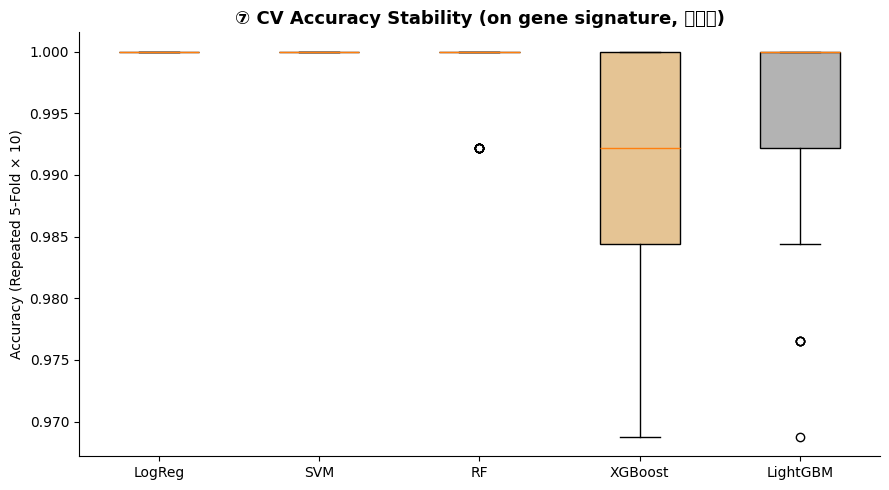

In [12]:

# 图: CV 准确率分布箱线图 (教程 09 的对比方式)
fig, ax = plt.subplots(figsize=(9, 5))
data_box = [cv_results[n]['acc'] for n in models]
bp = ax.boxplot(data_box, tick_labels=list(models.keys()), patch_artist=True, widths=0.5)
for patch, c in zip(bp['boxes'], plt.cm.Set2(np.linspace(0, 1, len(models)))):
    patch.set_facecolor(c)
ax.set_ylabel('Accuracy (Repeated 5-Fold × 10)')
ax.set_title('⑦ CV Accuracy Stability (on gene signature, 多分类)',
             fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "21_cv_model_comparison.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("\n  [图] 21_cv_model_comparison.png → CV 模型对比箱线图已保存")

In [13]:


# --- 在测试集上评估 (holdout) ---
print("\n  ▶ 测试集 (holdout, 20% = {} 样本) 最终评估:".format(len(X_test)))
print(f"     {'Model':<10} {'Acc':>7} {'F1_macro':>9} {'F1_weight':>10} {'AUC_macro':>10}")
print(f"     {'-'*10} {'-'*7} {'-'*9} {'-'*10} {'-'*10}")
test_results = {}
for name, model in models.items():
    model.fit(X_train_sig, y_train)
    pred = model.predict(X_test_sig)
    prob = model.predict_proba(X_test_sig)
    test_results[name] = {
        'acc': accuracy_score(y_test, pred),
        'f1_macro': f1_score(y_test, pred, average='macro'),
        'f1_weight': f1_score(y_test, pred, average='weighted'),
        'auc_macro': roc_auc_score(y_test, prob, multi_class='ovr',
                                    average='macro', labels=list(range(n_classes))),
        'pred': pred, 'prob': prob, 'model': model,
    }
    r = test_results[name]
    print(f"     {name:<10} {r['acc']:>7.4f} {r['f1_macro']:>9.4f} "
          f"{r['f1_weight']:>10.4f} {r['auc_macro']:>10.4f}")

# 选最佳模型 (按测试 macro-F1 — 对少数类公平的指标)
best_name = max(test_results, key=lambda k: test_results[k]['f1_macro'])
best_model = test_results[best_name]['model']
print(f"\n  ▶ 最佳模型 (测试 macro-F1 最高): {best_name}  "
      f"F1_macro={test_results[best_name]['f1_macro']:.4f}  "
      f"Acc={test_results[best_name]['acc']:.4f}")

# 保存模型对比结果
cv_summary = pd.DataFrame({
    'Model': list(models.keys()),
    'CV_Acc_mean': [cv_results[n]['acc'].mean() for n in models],
    'CV_Acc_std':  [cv_results[n]['acc'].std() for n in models],
    'CV_F1_macro': [cv_results[n]['f1'].mean() for n in models],
    'CV_AUC_macro':[cv_results[n]['auc'].mean() for n in models],
    'Test_Acc':    [test_results[n]['acc'] for n in models],
    'Test_F1_macro':[test_results[n]['f1_macro'] for n in models],
    'Test_AUC_macro':[test_results[n]['auc_macro'] for n in models],
})
cv_summary.to_csv(os.path.join(RESULTS_DIR, "21_model_comparison.csv"), index=False)
print("  📄 21_model_comparison.csv → CV+测试集对比已保存")



  ▶ 测试集 (holdout, 20% = 161 样本) 最终评估:
     Model          Acc  F1_macro  F1_weight  AUC_macro
     ---------- ------- --------- ---------- ----------
     LogReg      0.9938    0.9947     0.9938     1.0000
     SVM         0.9938    0.9947     0.9938     0.9999
     RF          0.9876    0.9848     0.9875     1.0000
     XGBoost     1.0000    1.0000     1.0000     1.0000
     LightGBM    1.0000    1.0000     1.0000     1.0000

  ▶ 最佳模型 (测试 macro-F1 最高): XGBoost  F1_macro=1.0000  Acc=1.0000
  📄 21_model_comparison.csv → CV+测试集对比已保存


In [14]:

# ============================================================================
# ⑧ 类别不平衡 — 对照教程 10
# ============================================================================
print("\n" + "=" * 70)
print("⑧ 类别不平衡  (对照教程 10)")
print("=" * 70)
print(f"  ▶ 5 类样本数: {dict(zip(class_names, class_counts.values))}")
print(f"     → 最大/最小类比例 = {imbalance:.1f} (BRCA {class_counts.max()} vs COAD {class_counts.min()})")
print(f"  ▶ 处理策略: 所有模型统一用 class_weight='balanced' (sklearn 自动按反频率加权)")
print(f"     → 相比 SMOTE 重采样的优势: ① 不引入合成样本 (基因表达合成生物学意义存疑);")
print(f"        ② 无重采样泄漏风险 (教程 10 强调: SMOTE 必须在 CV 内部, 不能跨折)")
print(f"     → 评估指标用 macro-F1 / AUC_macro (对少数类公平, 教程 10 的指标选择原则)")



⑧ 类别不平衡  (对照教程 10)
  ▶ 5 类样本数: {'BRCA': np.int64(300), 'COAD': np.int64(78), 'KIRC': np.int64(146), 'LUAD': np.int64(141), 'PRAD': np.int64(136)}
     → 最大/最小类比例 = 3.8 (BRCA 300 vs COAD 78)
  ▶ 处理策略: 所有模型统一用 class_weight='balanced' (sklearn 自动按反频率加权)
     → 相比 SMOTE 重采样的优势: ① 不引入合成样本 (基因表达合成生物学意义存疑);
        ② 无重采样泄漏风险 (教程 10 强调: SMOTE 必须在 CV 内部, 不能跨折)
     → 评估指标用 macro-F1 / AUC_macro (对少数类公平, 教程 10 的指标选择原则)



⑨ 评估可视化: 混淆矩阵 + per-class ROC + 校准  (对照教程 11)
  [图] 21_evaluation_multiclass.png → 混淆矩阵+per-class ROC+校准已保存


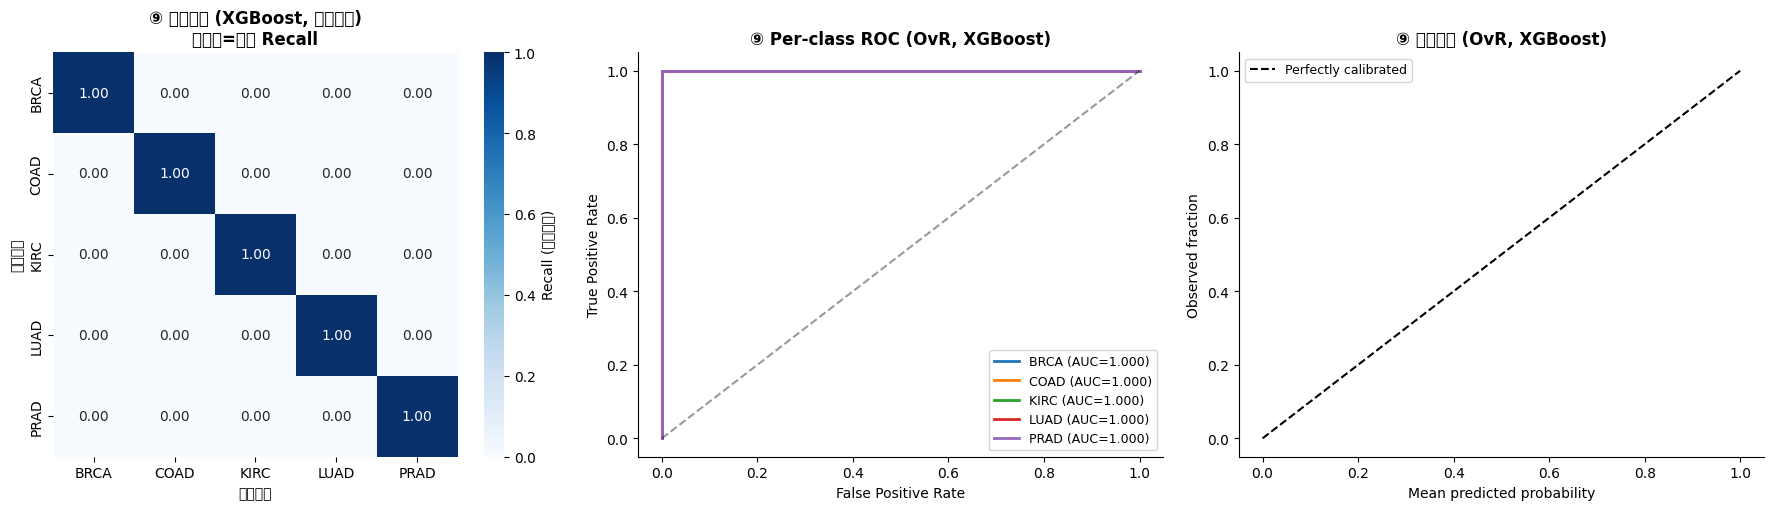

In [15]:

# ============================================================================
# ⑨ 混淆矩阵 + per-class ROC + 校准 — 对照教程 11
# ============================================================================
print("\n" + "=" * 70)
print("⑨ 评估可视化: 混淆矩阵 + per-class ROC + 校准  (对照教程 11)")
print("=" * 70)

best_pred = test_results[best_name]['pred']
best_prob = test_results[best_name]['prob']

# 9a. 混淆矩阵 (多分类核心评估 — 看哪些类被混淆)
cm = confusion_matrix(y_test, best_pred, normalize='true')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0],
            cbar_kws={'label': 'Recall (行归一化)'}, square=True)
axes[0].set_xlabel('预测类别'); axes[0].set_ylabel('真实类别')
axes[0].set_title(f'⑨ 混淆矩阵 ({best_name}, 行归一化)\n对角线=各类 Recall',
                  fontsize=12, fontweight='bold')

# 9b. per-class ROC (OvR, 多分类标准画法)
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))
for c in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, c], best_prob[:, c])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, lw=2, label=f'{class_names[c]} (AUC={roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'⑨ Per-class ROC (OvR, {best_name})', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9, loc='lower right')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

# 9c. 校准曲线 (取样本最多的 BRCA 类做 OvR 校准示例 + 少数类 COAD 对比)
for c, col in zip([0, 1], ['#e74c3c', '#3498db']):   # BRCA(idx0字母序) 与 COAD(idx1)
    mask = (y_test == c) | (best_prob.argmax(axis=1) == c)  # 相关样本
    if mask.sum() < 10:
        continue
    prob_c = best_prob[:, c][mask]
    y_c = (y_test == c).astype(int)[mask]
    if len(np.unique(y_c)) < 2:
        continue
    frac_pos, mean_pred = calibration_curve(y_c, prob_c, n_bins=5, strategy='uniform')
    brier = brier_score_loss(y_c, prob_c)
    axes[2].plot(mean_pred, frac_pos, 's-', color=col,
                 label=f'{class_names[c]} (Brier={brier:.3f})')
axes[2].plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
axes[2].set_xlabel('Mean predicted probability'); axes[2].set_ylabel('Observed fraction')
axes[2].set_title(f'⑨ 校准曲线 (OvR, {best_name})', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9); axes[2].spines['top'].set_visible(False); axes[2].spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "21_evaluation_multiclass.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 21_evaluation_multiclass.png → 混淆矩阵+per-class ROC+校准已保存")

In [16]:

# 每类指标表
per_class_rows = []
for c in range(n_classes):
    mask = (y_test == c)
    if mask.sum() == 0:
        continue
    pred_c = (best_pred == c)
    tp = np.sum(pred_c & mask); fp = np.sum(pred_c & ~mask); fn = np.sum(~pred_c & mask)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    per_class_rows.append({'Cancer': class_names[c], 'Support': int(mask.sum()),
                           'Precision': prec, 'Recall': rec, 'F1': f1})
per_class_df = pd.DataFrame(per_class_rows)
per_class_df.to_csv(os.path.join(RESULTS_DIR, "21_per_class_metrics.csv"), index=False)
print("\n  ▶ 每类指标 (测试集):")
print(f"     {'Cancer':<8} {'Support':>8} {'Precision':>10} {'Recall':>8} {'F1':>6}")
print(f"     {'-'*8} {'-'*8} {'-'*10} {'-'*8} {'-'*6}")
for _, r in per_class_df.iterrows():
    print(f"     {r['Cancer']:<8} {int(r['Support']):>8} {r['Precision']:>10.4f} "
          f"{r['Recall']:>8.4f} {r['F1']:>6.4f}")
print("  📄 21_per_class_metrics.csv → 每类指标已保存")


  ▶ 每类指标 (测试集):
     Cancer    Support  Precision   Recall     F1
     -------- -------- ---------- -------- ------
     BRCA           60     1.0000   1.0000 1.0000
     COAD           16     1.0000   1.0000 1.0000
     KIRC           30     1.0000   1.0000 1.0000
     LUAD           28     1.0000   1.0000 1.0000
     PRAD           27     1.0000   1.0000 1.0000
  📄 21_per_class_metrics.csv → 每类指标已保存


In [17]:

# ============================================================================
# ⑨b 多分类综合评估 (补充) — 对照教程 09/10/11
# ============================================================================
# 单一 Accuracy 在【多分类 + 轻度不平衡】下会掩盖少数类表现 (教程 10 的准确率悖论):
#   例: 若只预测多数类 BRCA, Accuracy 仍可达 300/801≈37%, 但 COAD(78 样本)全错.
# 因此多分类必须用一组专用指标交叉验证模型质量, 本节给出"多分类评估全家桶":
#   [1] classification_report — 每类 P/R/F1 + macro/weighted 平均 (教程 09 标准)
#   [2] 多分类汇总指标 — Balanced Acc / Cohen's κ / MCC / Top-2 / AUC (教程 09/11)
#   [3] 5 模型横向对比 — 谁对少数类更友好 (κ/MCC 同时高才稳健)
#   [4] 每类 AUC / AP 表 — 各类可分性 (OvR)
# 配 4 联可视化图: 计数混淆矩阵 / per-class PR / 每类指标柱 / 5 模型对比
print("\n" + "=" * 70)
print("⑨b 多分类综合评估 (补充): 多分类专用指标全家桶  (对照教程 09/10/11)")
print("=" * 70)
print("  ▶ 动机: 多分类 + 轻度不平衡下, 单看 Accuracy 会掩盖少数类 (COAD) 表现")
print("     → 必须用一组多分类专用指标交叉验证模型质量:")
print("        - macro/weighted 平均 (少数类等权 vs 按样本量加权)")
print("        - Balanced Accuracy (各类 Recall 均值, 抗不平衡, 教程 10)")
print("        - Cohen's Kappa (扣除随机一致的一致性, 0.8+ 几乎完美)")
print("        - MCC (Matthews 相关系数, 多分类最稳健单值, -1~1)")
print("        - Top-2 Accuracy (5 类下看“接近”是否命中, 衡量排序质量)")
print("        - 每类 PR 曲线 + AP (不平衡下比 ROC 更敏感, 教程 11)")

# --- 9b-1. 最佳模型完整 classification report (含 macro/weighted 平均) ---
print("\n  ▶ [1] 最佳模型 ({}) classification_report (含 macro/weighted 平均):".format(best_name))
report = classification_report(y_test, best_pred, target_names=class_names,
                               digits=4, output_dict=True, zero_division=0)
acc_val = report.pop('accuracy', None)              # accuracy 是标量, 单独取出避免破坏 DataFrame
report_df = pd.DataFrame(report).T
report_df.index.name = 'Cancer'
report_df = report_df.round(4)
report_df.to_csv(os.path.join(RESULTS_DIR, "21_multiclass_classification_report.csv"))
print(f"     {'Class':<12} {'Precision':>10} {'Recall':>10} {'F1':>8} {'Support':>8}")
print(f"     {'-'*12} {'-'*10} {'-'*10} {'-'*8} {'-'*8}")
for cname in list(class_names) + ['macro avg', 'weighted avg']:
    if cname in report_df.index:
        r = report_df.loc[cname]
        sup = int(r['support'])
        print(f"     {cname:<12} {r['precision']:>10.4f} {r['recall']:>10.4f} "
              f"{r['f1-score']:>8.4f} {sup:>8}")
if acc_val is not None:
    print(f"     {'(accuracy)':<12} {'':>10} {'':>10} {acc_val:>8.4f} {'':>8}")
print("  📄 21_multiclass_classification_report.csv → 完整 classification report 已保存")


# --- 9b-2. 多分类汇总指标 (Balanced Acc / κ / MCC / Top-2 / AUC) ---
def top_k_accuracy(y_true, prob, k=2):
    """top-k accuracy: 真实类是否落在预测概率最高的前 k 类中 (衡量排序质量)."""
    topk_idx = np.argsort(-prob, axis=1)[:, :k]
    return float(np.mean([y_true[i] in topk_idx[i] for i in range(len(y_true))]))

mc_summary = {
    'Accuracy':        accuracy_score(y_test, best_pred),
    'Balanced_Acc':     balanced_accuracy_score(y_test, best_pred),
    'Macro_Precision':  precision_score(y_test, best_pred, average='macro', zero_division=0),
    'Macro_Recall':     recall_score(y_test, best_pred, average='macro', zero_division=0),
    'Macro_F1':         f1_score(y_test, best_pred, average='macro'),
    'Weighted_F1':      f1_score(y_test, best_pred, average='weighted'),
    'Cohen_Kappa':      cohen_kappa_score(y_test, best_pred),
    'MCC':              matthews_corrcoef(y_test, best_pred),
    'Top2_Accuracy':    top_k_accuracy(y_test, best_prob, k=2),
    'Macro_AUC_OvR':    roc_auc_score(y_test, best_prob, multi_class='ovr',
                                     average='macro', labels=list(range(n_classes))),
    'Weighted_AUC_OvR': roc_auc_score(y_test, best_prob, multi_class='ovr',
                                     average='weighted', labels=list(range(n_classes))),
}
_explain = {
    'Accuracy':        '原始准确率 (多数类主导, 易高估)',
    'Balanced_Acc':    '各类 Recall 均值 (抗不平衡, 教程 10)',
    'Macro_Precision': '各类 Precision 简单平均 (COAD 等权)',
    'Macro_Recall':    '各类 Recall 简单平均 (少数类等权)',
    'Macro_F1':        '各类 F1 简单平均 (对少数类公平)',
    'Weighted_F1':     '按样本量加权 F1 (整体偏向多数类)',
    'Cohen_Kappa':     "扣除随机一致 κ (0.8+ 几乎完美一致)",
    'MCC':             'Matthews 相关系数 (多分类最稳健单值, -1~1)',
    'Top2_Accuracy':   'Top-2 准确率 (5 类下"接近"即算对)',
    'Macro_AUC_OvR':   'OvR macro AUC (各类等权, 教程 09)',
    'Weighted_AUC_OvR':'OvR 按样本量加权 AUC',
}
print(f"\n  ▶ [2] 多分类汇总指标 (最佳模型 {best_name}):")
print(f"     {'指标':<18} {'值':>10}  说明")
print(f"     {'-'*18} {'-'*10}")
for k, v in mc_summary.items():
    print(f"     {k:<18} {v:>10.4f}  {_explain.get(k, '')}")



⑨b 多分类综合评估 (补充): 多分类专用指标全家桶  (对照教程 09/10/11)
  ▶ 动机: 多分类 + 轻度不平衡下, 单看 Accuracy 会掩盖少数类 (COAD) 表现
     → 必须用一组多分类专用指标交叉验证模型质量:
        - macro/weighted 平均 (少数类等权 vs 按样本量加权)
        - Balanced Accuracy (各类 Recall 均值, 抗不平衡, 教程 10)
        - Cohen's Kappa (扣除随机一致的一致性, 0.8+ 几乎完美)
        - MCC (Matthews 相关系数, 多分类最稳健单值, -1~1)
        - Top-2 Accuracy (5 类下看“接近”是否命中, 衡量排序质量)
        - 每类 PR 曲线 + AP (不平衡下比 ROC 更敏感, 教程 11)

  ▶ [1] 最佳模型 (XGBoost) classification_report (含 macro/weighted 平均):
     Class         Precision     Recall       F1  Support
     ------------ ---------- ---------- -------- --------
     BRCA             1.0000     1.0000   1.0000       60
     COAD             1.0000     1.0000   1.0000       16
     KIRC             1.0000     1.0000   1.0000       30
     LUAD             1.0000     1.0000   1.0000       28
     PRAD             1.0000     1.0000   1.0000       27
     macro avg        1.0000     1.0000   1.0000      161
     weighted avg     1.0000     1.0000   1.0000 

In [18]:

# --- 9b-3. 5 模型多分类指标横向对比 (谁对少数类更友好) ---
print("\n  ▶ [3] 5 个模型多分类指标横向对比 (κ/MCC 同时高才真稳健):")
all_mc_rows = []
for name in models:
    _pred = test_results[name]['pred']
    _prob = test_results[name]['prob']
    all_mc_rows.append({
        'Model':         name,
        'Accuracy':      accuracy_score(y_test, _pred),
        'Balanced_Acc':  balanced_accuracy_score(y_test, _pred),
        'Macro_F1':      f1_score(y_test, _pred, average='macro'),
        'Weighted_F1':   f1_score(y_test, _pred, average='weighted'),
        'Cohen_Kappa':   cohen_kappa_score(y_test, _pred),
        'MCC':           matthews_corrcoef(y_test, _pred),
        'Top2_Acc':      top_k_accuracy(y_test, _prob, k=2),
        'Macro_AUC':     roc_auc_score(y_test, _prob, multi_class='ovr', average='macro',
                                       labels=list(range(n_classes))),
    })
all_mc_df = pd.DataFrame(all_mc_rows).round(4)
all_mc_df.to_csv(os.path.join(RESULTS_DIR, "21_multiclass_summary_metrics.csv"), index=False)
print(all_mc_df.to_string(index=False))
print("\n  → 解读: Macro_F1 / κ / MCC 同时高 = 不仅整体对, 各类也对 (尤其少数类 COAD)")
print("  📄 21_multiclass_summary_metrics.csv → 5 模型多分类指标对比已保存")


  ▶ [3] 5 个模型多分类指标横向对比 (κ/MCC 同时高才真稳健):
   Model  Accuracy  Balanced_Acc  Macro_F1  Weighted_F1  Cohen_Kappa    MCC  Top2_Acc  Macro_AUC
  LogReg    0.9938        0.9929    0.9947       0.9938       0.9918 0.9918       1.0     1.0000
     SVM    0.9938        0.9929    0.9947       0.9938       0.9918 0.9918       1.0     0.9999
      RF    0.9876        0.9804    0.9848       0.9875       0.9836 0.9836       1.0     1.0000
 XGBoost    1.0000        1.0000    1.0000       1.0000       1.0000 1.0000       1.0     1.0000
LightGBM    1.0000        1.0000    1.0000       1.0000       1.0000 1.0000       1.0     1.0000

  → 解读: Macro_F1 / κ / MCC 同时高 = 不仅整体对, 各类也对 (尤其少数类 COAD)
  📄 21_multiclass_summary_metrics.csv → 5 模型多分类指标对比已保存



  [图] 21_multiclass_evaluation.png → 4 联多分类评估图已保存
     (a) 计数混淆矩阵  (b) 每类 PR 曲线  (c) 每类指标  (d) 5 模型对比

  ▶ [4] 每类 AUC / AP (OvR, 最佳模型 XGBoost):
     Cancer    Support      AUC       AP
     -------- -------- -------- --------
     BRCA           60   1.0000   1.0000
     COAD           16   1.0000   1.0000
     KIRC           30   1.0000   1.0000
     LUAD           28   1.0000   1.0000
     PRAD           27   1.0000   1.0000
  → AUC=排序能力(1=完美), AP=正类预测质量(受不平衡影响, 少数类 AP 会低)
  📄 21_per_class_auc_ap.csv → 每类 AUC/AP 已保存


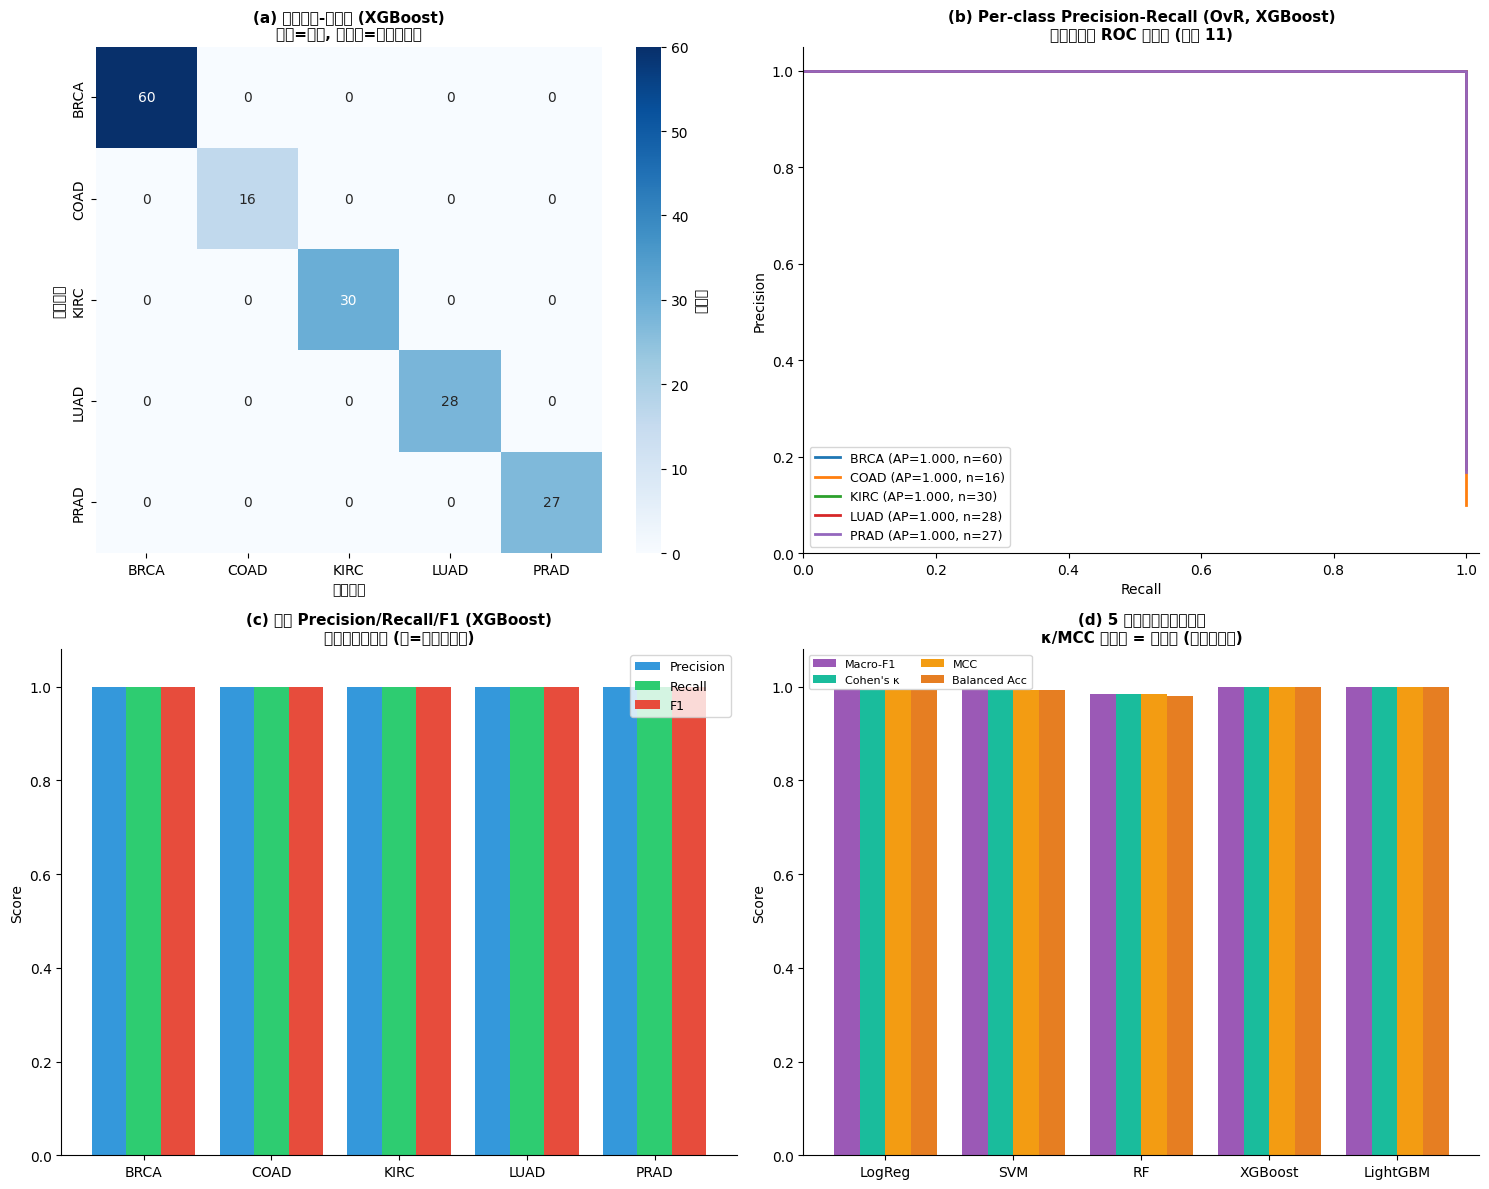

In [19]:

# --- 9b-4. 多分类评估 4 联可视化 ---
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# (a) 计数混淆矩阵 (绝对数, 看错配样本数 — 与 ⑨ 的归一化版互补)
cm_count = confusion_matrix(y_test, best_pred)
sns.heatmap(cm_count, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0, 0],
            cbar_kws={'label': '样本数'}, square=True)
axes[0, 0].set_xlabel('预测类别'); axes[0, 0].set_ylabel('真实类别')
axes[0, 0].set_title(f'(a) 混淆矩阵-计数版 ({best_name})\n对角=正确, 非对角=错配样本数',
                     fontsize=11, fontweight='bold')

# (b) 每类 PR 曲线 (OvR) — 不平衡下比 ROC 更敏感 (教程 11)
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))
for c in range(n_classes):
    prec_pc, rec_pc, _ = precision_recall_curve(y_test_bin[:, c], best_prob[:, c])
    ap_c = average_precision_score(y_test_bin[:, c], best_prob[:, c])
    axes[0, 1].plot(rec_pc, prec_pc, lw=2,
                    label=f'{class_names[c]} (AP={ap_c:.3f}, n={int(y_test_bin[:, c].sum())})')
axes[0, 1].set_xlabel('Recall'); axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title(f'(b) Per-class Precision-Recall (OvR, {best_name})\n'
                     '不平衡下比 ROC 更敏感 (教程 11)',
                     fontsize=11, fontweight='bold')
axes[0, 1].legend(fontsize=9, loc='lower left')
axes[0, 1].set_xlim(0, 1.02); axes[0, 1].set_ylim(0, 1.05)
axes[0, 1].spines['top'].set_visible(False); axes[0, 1].spines['right'].set_visible(False)

# (c) 每类 Precision/Recall/F1 分组柱状图 (看各类表现均衡度)
x_pos = np.arange(n_classes)
width = 0.27
prec_list = [report[cn]['precision'] for cn in class_names]
rec_list  = [report[cn]['recall']    for cn in class_names]
f1_list   = [report[cn]['f1-score']  for cn in class_names]
axes[1, 0].bar(x_pos - width, prec_list, width, label='Precision', color='#3498db')
axes[1, 0].bar(x_pos,         rec_list,  width, label='Recall',    color='#2ecc71')
axes[1, 0].bar(x_pos + width, f1_list,   width, label='F1',       color='#e74c3c')
axes[1, 0].set_xticks(x_pos); axes[1, 0].set_xticklabels(class_names)
axes[1, 0].set_ylim(0, 1.08); axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title(f'(c) 每类 Precision/Recall/F1 ({best_name})\n'
                     '看各类是否均衡 (低=该类判别弱)',
                     fontsize=11, fontweight='bold')
axes[1, 0].legend(fontsize=9)
axes[1, 0].spines['top'].set_visible(False); axes[1, 0].spines['right'].set_visible(False)

# (d) 5 模型多分类指标对比 (Macro-F1 / κ / MCC / Balanced-Acc)
metrics_plot = ['Macro_F1', 'Cohen_Kappa', 'MCC', 'Balanced_Acc']
metric_labels = ['Macro-F1', "Cohen's κ", 'MCC', 'Balanced Acc']
x_pos2 = np.arange(len(models))
width2 = 0.2
colors_m = ['#9b59b6', '#1abc9c', '#f39c12', '#e67e22']
for i, (m, lab, col) in enumerate(zip(metrics_plot, metric_labels, colors_m)):
    axes[1, 1].bar(x_pos2 + (i - 1.5) * width2, all_mc_df[m].values, width2,
                   label=lab, color=col)
axes[1, 1].set_xticks(x_pos2); axes[1, 1].set_xticklabels(list(models.keys()))
axes[1, 1].set_ylim(0, 1.08); axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title(f'(d) 5 模型多分类指标对比\n'
                     'κ/MCC 同时高 = 真稳健 (非靠多数类)',
                     fontsize=11, fontweight='bold')
axes[1, 1].legend(fontsize=8, ncol=2)
axes[1, 1].spines['top'].set_visible(False); axes[1, 1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "21_multiclass_evaluation.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("\n  [图] 21_multiclass_evaluation.png → 4 联多分类评估图已保存")
print("     (a) 计数混淆矩阵  (b) 每类 PR 曲线  (c) 每类指标  (d) 5 模型对比")


# --- 9b-5. 每类 AUC / AP 表 (OvR, 看每类可分性) ---
per_auc_rows = []
for c in range(n_classes):
    mask_c = (y_test == c).astype(int)
    auc_c = roc_auc_score(mask_c, best_prob[:, c])
    ap_c  = average_precision_score(mask_c, best_prob[:, c])
    per_auc_rows.append({'Cancer': class_names[c], 'Support': int(mask_c.sum()),
                         'AUC_OvR': round(auc_c, 4), 'AP_OvR': round(ap_c, 4)})
per_auc_df = pd.DataFrame(per_auc_rows)
per_auc_df.to_csv(os.path.join(RESULTS_DIR, "21_per_class_auc_ap.csv"), index=False)
print(f"\n  ▶ [4] 每类 AUC / AP (OvR, 最佳模型 {best_name}):")
print(f"     {'Cancer':<8} {'Support':>8} {'AUC':>8} {'AP':>8}")
print(f"     {'-'*8} {'-'*8} {'-'*8} {'-'*8}")
for _, r in per_auc_df.iterrows():
    print(f"     {r['Cancer']:<8} {int(r['Support']):>8} {r['AUC_OvR']:>8.4f} {r['AP_OvR']:>8.4f}")
print("  → AUC=排序能力(1=完美), AP=正类预测质量(受不平衡影响, 少数类 AP 会低)")
print("  📄 21_per_class_auc_ap.csv → 每类 AUC/AP 已保存")


⑩ SHAP 可解释性分析 (多分类)  (对照教程 12)
  ▶ 解释模型: XGBoost (树模型 → shap.TreeExplainer, 高效精确)
  ▶ SHAP 值形状: (161, 92, 5)  = (样本, 基因, 类别)
  ▶ SHAP Top-20 重要基因 (跨 5 类汇总):
     gene_12983     |SHAP|=1.6091
     gene_18135     |SHAP|=1.4521
     gene_18746     |SHAP|=1.1816
     gene_15899     |SHAP|=1.1801
     gene_17801     |SHAP|=1.0506
     gene_11910     |SHAP|=1.0195
     gene_7964      |SHAP|=0.8626
     gene_13639     |SHAP|=0.7404
     gene_3523      |SHAP|=0.7296
     gene_12013     |SHAP|=0.5825

  [图] 21_shap_importance.png → SHAP 全局重要性柱状图已保存
  [图] 21_shap_beeswarm.png → SHAP 蜂群图(全局)已保存
  [图] 21_shap_waterfall.png → SHAP 瀑布图(局部)已保存
  [图] 21_shap_class_markers.png → 各类标志基因热力图已保存
  📄 21_shap_importance.csv → SHAP 重要性已保存


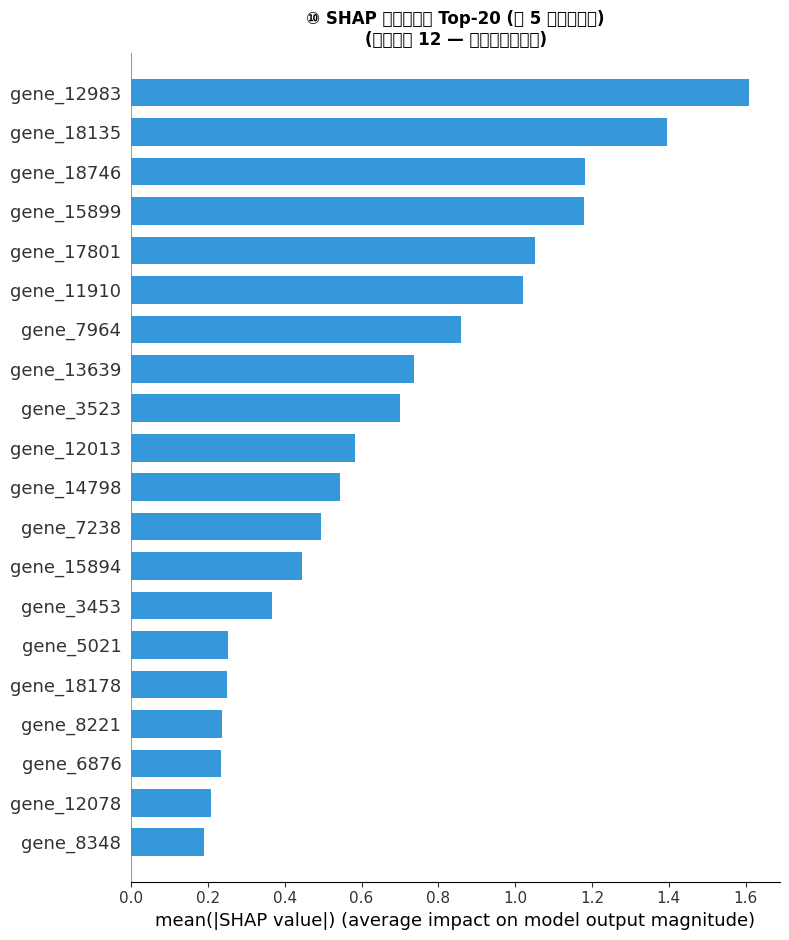

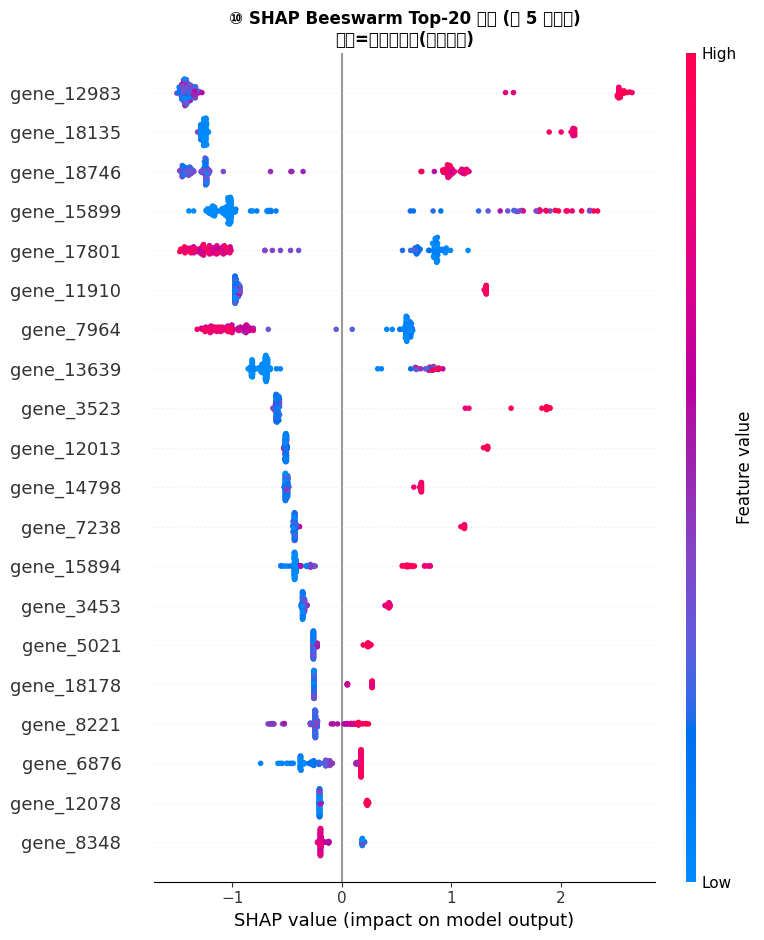

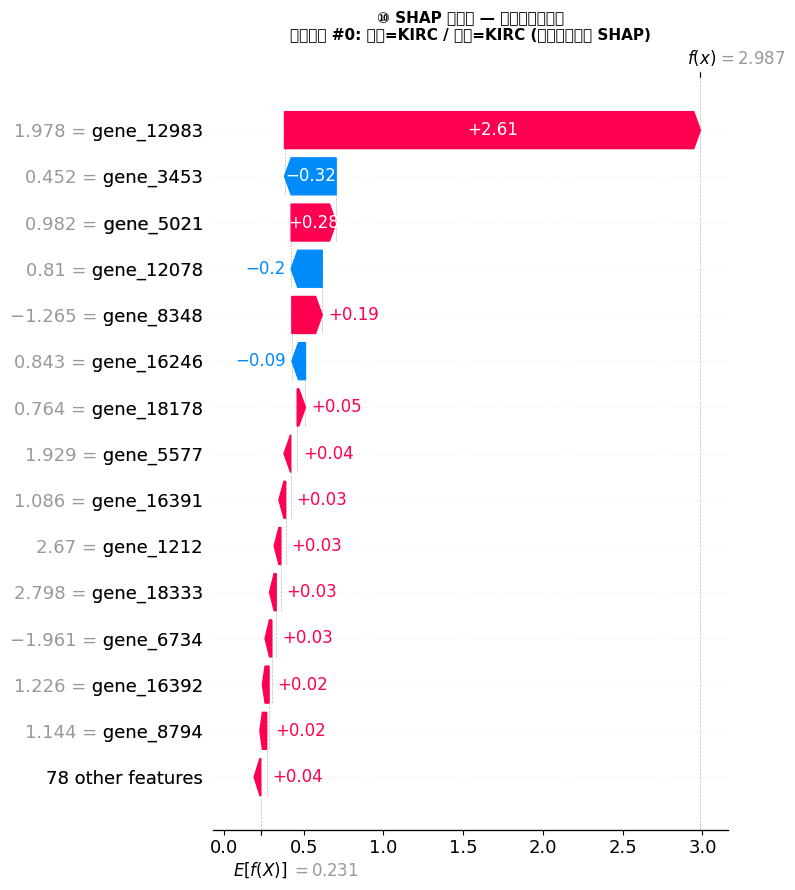

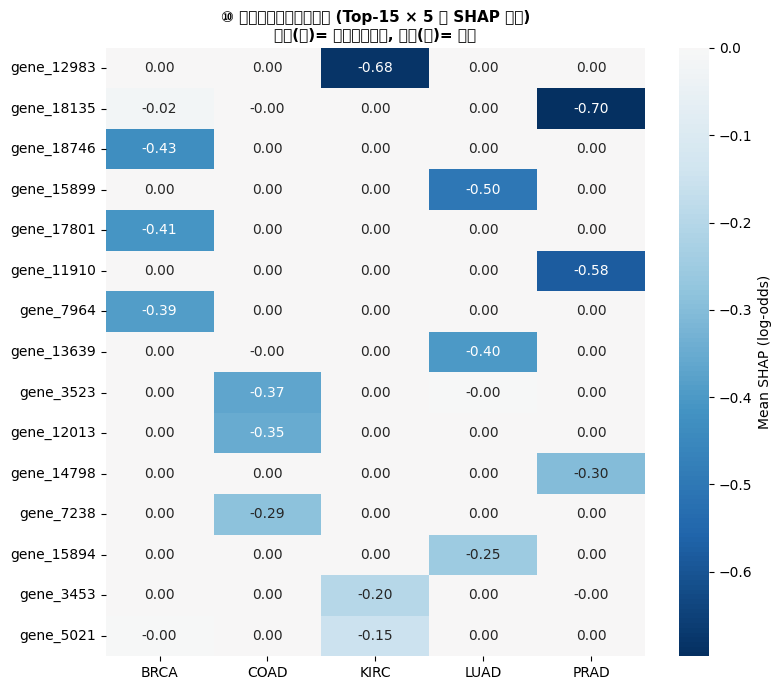

In [20]:

# ============================================================================
# ⑩ SHAP 可解释性分析 (多分类) — 对照教程 12
# ============================================================================
print("\n" + "=" * 70)
print("⑩ SHAP 可解释性分析 (多分类)  (对照教程 12)")
print("=" * 70)

# 用树模型做 SHAP (RF/XGBoost/LightGBM 任一); 优先用最佳模型若是树模型, 否则用 XGBoost
shap_model_name = best_name if best_name in ('RF', 'XGBoost', 'LightGBM') else 'XGBoost'
shap_model = test_results[shap_model_name]['model']
print(f"  ▶ 解释模型: {shap_model_name} (树模型 → shap.TreeExplainer, 高效精确)")

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test_sig)
# 多分类树模型: shap_values 形状 (n_samples, n_features, n_classes)
if isinstance(shap_values, list):
    sv_arr = np.stack(shap_values, axis=-1)   # (n_samples, n_features, n_classes)
else:
    sv_arr = np.asarray(shap_values)
    if sv_arr.ndim == 2:                       # 单输出 (罕见), 扩展最后一维
        sv_arr = sv_arr[..., None]
print(f"  ▶ SHAP 值形状: {sv_arr.shape}  = (样本, 基因, 类别)")

# 全局重要性: 各类别 |SHAP| 取均值后, 再对类别求和 → 该基因跨所有类的总贡献
# (多分类 SHAP 标准聚合方式: 见 Lundberg & Lee, NeurIPS 2017)
global_importance = np.abs(sv_arr).mean(axis=0).sum(axis=1)   # (n_genes,)
imp_order = np.argsort(-global_importance)
top_n_display = 20
top_genes_idx = imp_order[:top_n_display]
print(f"  ▶ SHAP Top-{top_n_display} 重要基因 (跨 5 类汇总):")
for k in top_genes_idx[:10]:
    print(f"     {signature_genes[k]:<14} |SHAP|={global_importance[k]:.4f}")

# 图1: SHAP 全局重要性柱状图 (Top-20)
plt.figure(figsize=(9, 7))
shap.summary_plot(sv_arr.sum(axis=2), X_test_sig,            # 跨类求和 → (n_samples, n_genes)
                  feature_names=list(signature_genes),
                  plot_type='bar', show=False, max_display=top_n_display,
                  color='#3498db')
plt.title('⑩ SHAP 全局重要性 Top-20 (跨 5 类癌症汇总)\n(对照教程 12 — 多分类聚合方式)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "21_shap_importance.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("\n  [图] 21_shap_importance.png → SHAP 全局重要性柱状图已保存")

# 图2: SHAP 蜂群图 (展示 Top-20 基因, 跨类求和后的全局贡献分布)
plt.figure(figsize=(9, 8))
shap.summary_plot(sv_arr.sum(axis=2), X_test_sig,
                  feature_names=list(signature_genes),
                  show=False, max_display=top_n_display)
plt.title('⑩ SHAP Beeswarm Top-20 基因 (跨 5 类汇总)\n颜色=基因表达值(红高蓝低)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "21_shap_beeswarm.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 21_shap_beeswarm.png → SHAP 蜂群图(全局)已保存")

# 图3: 单样本瀑布图 (局部解释 — 该样本被预测为哪一类, 就看哪一类的 SHAP)
sample_idx = 0
pred_class = int(np.argmax(best_prob[sample_idx]))
true_class = int(y_test[sample_idx])
sv_sample = sv_arr[sample_idx, :, pred_class]                # 该样本在【预测类】上的 SHAP
exp_val = explainer.expected_value
ev = exp_val[pred_class] if (hasattr(exp_val, '__len__') and np.size(exp_val) > 1) else exp_val

plt.figure(figsize=(9, 8))
shap.waterfall_plot(shap.Explanation(values=sv_sample,
                                     base_values=ev,
                                     data=X_test_sig[sample_idx],
                                     feature_names=list(signature_genes)),
                    max_display=15, show=False)
plt.title(f'⑩ SHAP 瀑布图 — 单样本局部解释\n'
          f'测试样本 #{sample_idx}: 真实={class_names[true_class]} / '
          f'预测={class_names[pred_class]} (展示预测类的 SHAP)',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "21_shap_waterfall.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 21_shap_waterfall.png → SHAP 瀑布图(局部)已保存")

# 图4: 每类 Top 基因热力图 (多分类特有 — 看哪些基因是哪类癌症的标志)
# 取每类 SHAP 均值, 看各类的标志性基因
class_mean_shap = sv_arr.mean(axis=0)     # (n_genes, n_classes)
# 取全局 Top-15 基因 × 5 类 的 SHAP 均值矩阵
top15 = imp_order[:15]
heat_df = pd.DataFrame(class_mean_shap[top15, :],
                      index=[signature_genes[i] for i in top15],
                      columns=class_names)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(heat_df, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            cbar_kws={'label': 'Mean SHAP (log-odds)'}, ax=ax)
ax.set_title('⑩ 各类癌症的标志性基因 (Top-15 × 5 类 SHAP 均值)\n'
             '正值(红)= 推高该类概率, 负值(蓝)= 推低',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "21_shap_class_markers.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 21_shap_class_markers.png → 各类标志基因热力图已保存")

# SHAP 重要性表格
shap_imp_df = pd.DataFrame({
    'gene': list(signature_genes),
    'mean_abs_shap': global_importance,
}).sort_values('mean_abs_shap', ascending=False)
shap_imp_df.to_csv(os.path.join(RESULTS_DIR, "21_shap_importance.csv"), index=False)
print("  📄 21_shap_importance.csv → SHAP 重要性已保存")

 
